---
title: The GEV distribution
subtitle: Modelling, fitting and assessing extremes at a single station
short_title: GEV at one station
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - generalized extreme value distribution
  - maximum likelihood
  - Bayesian inference
  - NUTS
  - goodness of fit
abstract: |
  With annual maxima in hand, we can finally ask what *distribution* they follow.
  Extreme-value theory answers with the Generalized Extreme Value (GEV) family.
  This notebook develops the GEV in full — density, support, the three tail
  types, and the return level — then fits it to one station's annual maxima by
  Bayesian inference with NumPyro's NUTS sampler, working through the likelihood,
  the priors, and the sampler diagnostics. We close by *assessing* the fit:
  PP- and QQ-plots, a density overlay, a return-level plot with credible bands,
  and goodness-of-fit scores (log-likelihood, AIC, BIC, the Kolmogorov–Smirnov
  statistic, and CRPS).
---

# The GEV distribution at one station

In [](01_block_maxima.ipynb) we reduced each station-year to a single annual
maximum. Those maxima are not arbitrary numbers: extreme-value theory says they
should follow one specific three-parameter family. Here we introduce that family,
fit it to a single station, and — just as importantly — check whether it actually
describes the data.

## Background

### The Generalized Extreme Value distribution

The **Generalized Extreme Value (GEV)** distribution is the limit law for block
maxima (the Fisher–Tippett–Gnedenko theorem). Its cumulative distribution
function is

```{math}
:label: eq:gev-cdf
G(z) \;=\; \exp\!\left\{-\left[1 + \xi\,\frac{z-\mu}{\sigma}\right]_{+}^{-1/\xi}\right\},
\qquad [\,a\,]_+ = \max(a, 0),
```

with **location** $\mu\in\mathbb{R}$, **scale** $\sigma>0$ and **shape**
$\xi\in\mathbb{R}$. Differentiating gives the density

```{math}
:label: eq:gev-pdf
g(z) \;=\; \frac{1}{\sigma}\,
\left[1 + \xi\,\frac{z-\mu}{\sigma}\right]_{+}^{-\frac{1}{\xi}-1}
\exp\!\left\{-\left[1 + \xi\,\frac{z-\mu}{\sigma}\right]_{+}^{-1/\xi}\right\}.
```

The $[\,\cdot\,]_+$ matters: the GEV has a **hard support boundary** at
$z = \mu - \sigma/\xi$. The sign of $\xi$ selects the tail type:

- $\xi \to 0$ — **Gumbel**: light, exponential tail, unbounded both ways;
- $\xi > 0$ — **Fréchet**: heavy, polynomial tail, lower-bounded;
- $\xi < 0$ — **Weibull**: short tail with a finite *upper* bound $\mu - \sigma/\xi$.

For temperature extremes $\xi$ answers a physical question: is there an effective
ceiling on the annual maximum ($\xi<0$), or not ($\xi\ge 0$)? Once fitted, the
model also lets us *predict* rare levels far beyond the observed record — the
**return levels** of their own section below.

### Inference

Given annual maxima $z_1,\dots,z_m$ assumed i.i.d. GEV, the **log-likelihood** is

```{math}
:label: eq:gev-loglik
\ell(\mu,\sigma,\xi) = -m\log\sigma
-\Bigl(1+\tfrac{1}{\xi}\Bigr)\sum_{i=1}^m \log\!\Bigl[1+\xi\tfrac{z_i-\mu}{\sigma}\Bigr]
-\sum_{i=1}^m \Bigl[1+\xi\tfrac{z_i-\mu}{\sigma}\Bigr]^{-1/\xi},
```

valid where every $1+\xi(z_i-\mu)/\sigma>0$. Maximising $\ell$ gives the MLE, but
with only a few dozen maxima the estimates — especially $\xi$ — are uncertain, so
we go **Bayesian**: with priors $p(\mu,\sigma,\xi)$ the posterior is

```{math}
:label: eq:posterior
p(\mu,\sigma,\xi \mid z_{1:m}) \;\propto\; p(z_{1:m}\mid\mu,\sigma,\xi)\,p(\mu,\sigma,\xi),
```

and we sample it with the **No-U-Turn Sampler (NUTS)**, a gradient-based MCMC
method. We use a tight prior on $\xi$ (weakly informative, mass on
$[-0.5, 0.5]$) and a high target acceptance, because the support boundary in
{eq}`eq:gev-cdf` makes the geometry stiff.

## Setup

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
jax.config.update("jax_enable_x64", True)        # GEV likelihood is boundary-sensitive

import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_log_prob

from spatial_extremes import data
from spatial_extremes.places import nearest_city

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

In [3]:
maxima, stations, years, is_real = data.load_annual_maxima(min_periods=300, min_years=20)
valid = np.isfinite(maxima).sum(1)
order = valid + np.nan_to_num(np.nanmean(maxima, axis=1)) / 1e3   # covered + warm
sidx = int(np.argmax(order))
lon, lat = float(stations[sidx, 0]), float(stations[sidx, 1])
city, dist = nearest_city(lon, lat)
place = city if dist < 12 else f"near {city}"
mask = np.isfinite(maxima[sidx])
y_np = maxima[sidx][mask]
yr_s = years[mask]
y = jnp.asarray(y_np)
y_mean, y_std = float(jnp.mean(y)), float(jnp.std(y))
print("source:", "REAL CDS" if is_real else "synthetic")
print(f"station at ({lon:.2f}°E, {lat:.2f}°N) — {place}, Spain")
print(f"{y.size} annual maxima, {y_np.min():.1f}–{y_np.max():.1f} °C")

source: REAL CDS
station at (0.49°E, 40.82°N) — near Zaragoza, Spain
120 annual maxima, 33.5–43.9 °C


These are the numbers we will model — the annual maximum temperature at this station, one value per year:

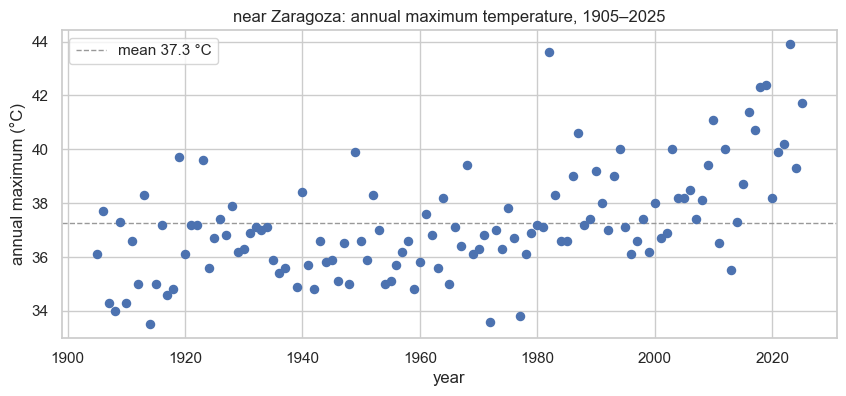

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(yr_s, y_np, color="#4C72B0", s=34, zorder=3)
ax.axhline(y_np.mean(), color="0.6", ls="--", lw=1, label=f"mean {y_np.mean():.1f} °C")
ax.set(xlabel="year", ylabel="annual maximum (°C)",
       title=f"{place}: annual maximum temperature, {int(yr_s.min())}–{int(yr_s.max())}")
ax.legend()
plt.show()

## The model

The NumPyro model is a one-to-one transcription of
{eq}`eq:posterior`: three priors and a GEV likelihood {eq}`eq:gev-pdf` (xtremax's
`GeneralizedExtremeValueDistribution`). The prior means are anchored to the data
scale; the $\xi$ prior is deliberately tight.

In [5]:
def gev_model(obs):
    # priors p(mu, sigma, xi)
    mu = numpyro.sample("mu", ndist.Normal(y_mean, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(y_std))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))      # ~ [-0.5, 0.5]
    # likelihood p(z | mu, sigma, xi)  — eq. (gev-pdf)
    numpyro.sample("obs", GEV(loc=mu, scale=sigma, concentration=xi), obs=obs)

## Inference with NUTS

NUTS explores the posterior {eq}`eq:posterior` using gradients of
$\log p(\mu,\sigma,\xi\mid z)$, automatically tuning its trajectory length. We
run **two chains** so we can check the Gelman–Rubin $\hat R$, raise
`target_accept_prob` to 0.95 (the GEV support boundary makes the geometry stiff),
and initialise at the prior median.

In [6]:
mcmc = MCMC(
    NUTS(gev_model, target_accept_prob=0.95, init_strategy=init_to_median),
    num_warmup=1500, num_samples=1500, num_chains=2,
    chain_method="vectorized", progress_bar=False,
)
mcmc.run(jr.PRNGKey(0), y)
mcmc.print_summary()
post = mcmc.get_samples()
n_div = int(mcmc.get_extra_fields()["diverging"].sum())
print(f"divergences: {n_div} / {post['mu'].size}")


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     36.36      0.17     36.37     36.07     36.64   1849.06      1.00
     sigma      1.69      0.13      1.68      1.49      1.90   1824.67      1.00
        xi     -0.04      0.06     -0.04     -0.14      0.06   1713.72      1.00

Number of divergences: 0
divergences: 0 / 3000


$\hat R\approx 1.0$ and a healthy effective sample size on all three parameters
mean the chains mixed; a near-zero divergence count means the stiff boundary
geometry was handled. Now look at the **joint posterior** — note how $\mu$ and
$\sigma$ trade off, and how wide the $\xi$ posterior is even with a clean fit
(the tail type is genuinely hard to pin down from ~25 numbers).

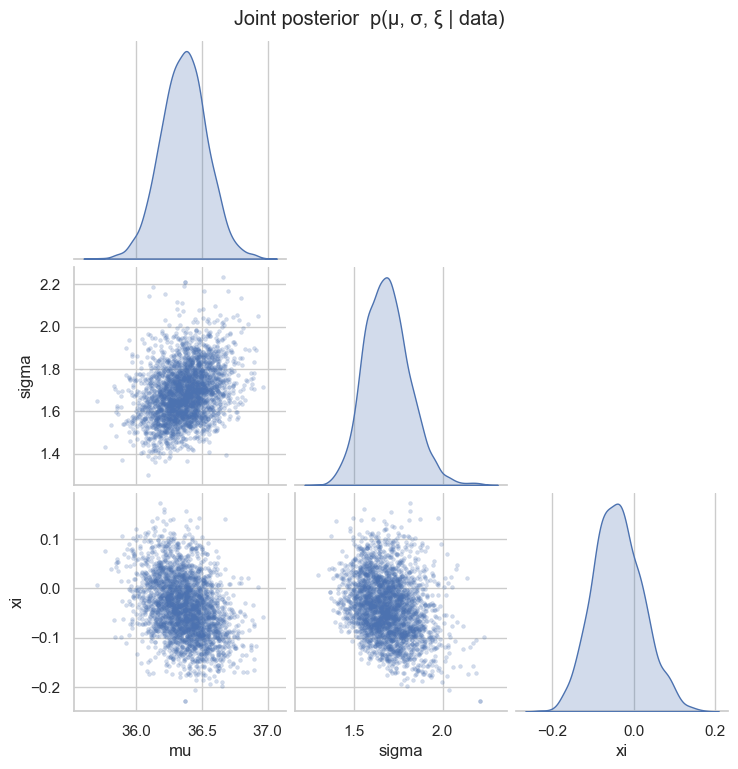

       lower 95%  median  upper 95%
mu        36.020  36.366     36.705
sigma      1.462   1.682      1.954
xi        -0.148  -0.041      0.088


In [7]:
draws = pd.DataFrame({k: np.asarray(post[k]) for k in ("mu", "sigma", "xi")})
g = sns.pairplot(draws, corner=True, diag_kind="kde",
                 plot_kws=dict(s=8, alpha=0.25, edgecolor=None),
                 diag_kws=dict(fill=True))
g.figure.suptitle("Joint posterior  p(μ, σ, ξ | data)", y=1.02)
plt.show()

summary = draws.describe(percentiles=[0.025, 0.5, 0.975]).T[["2.5%", "50%", "97.5%"]]
summary.columns = ["lower 95%", "median", "upper 95%"]
print(summary.round(3).to_string())

## Does the model fit?

A posterior is only useful if the model describes the data. We assess the fit
three ways, all built from xtremax's distribution methods on the posterior-median
parameters.

**PP- and QQ-plots.** Sorting the maxima $z_{(1)}\le\dots\le z_{(m)}$ and using
plotting positions $p_i=(i-0.5)/m$, the **PP-plot** compares the fitted CDF
$\hat G(z_{(i)})$ against $p_i$, and the **QQ-plot** compares the fitted quantiles
$\hat G^{-1}(p_i)$ against the observed $z_{(i)}$. Points on the diagonal mean a
good fit.

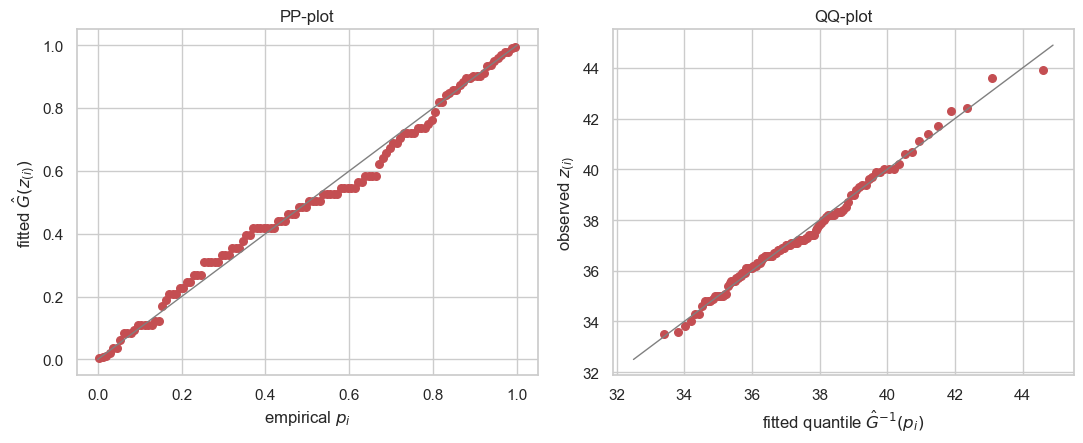

In [8]:
mu_m, sig_m, xi_m = (float(np.median(post[k])) for k in ("mu", "sigma", "xi"))
fit = GEV(loc=mu_m, scale=sig_m, concentration=xi_m)

zs = np.sort(y_np)
m = zs.size
p = (np.arange(1, m + 1) - 0.5) / m
cdf_fit = np.asarray(fit.cdf(jnp.asarray(zs)))
q_fit = np.asarray(fit.icdf(jnp.asarray(p)))

fig, (axp, axq) = plt.subplots(1, 2, figsize=(11, 4.6))
axp.plot([0, 1], [0, 1], color="0.5", lw=1)
axp.scatter(p, cdf_fit, color="#C44E52", s=30)
axp.set(xlabel="empirical $p_i$", ylabel=r"fitted $\hat G(z_{(i)})$", title="PP-plot")
lim = [zs.min() - 1, zs.max() + 1]
axq.plot(lim, lim, color="0.5", lw=1)
axq.scatter(q_fit, zs, color="#C44E52", s=30)
axq.set(xlabel=r"fitted quantile $\hat G^{-1}(p_i)$", ylabel=r"observed $z_{(i)}$",
        title="QQ-plot")
fig.tight_layout()
plt.show()

**Density overlay.** Finally, the fitted density {eq}`eq:gev-pdf` should track
the histogram of the observed maxima.

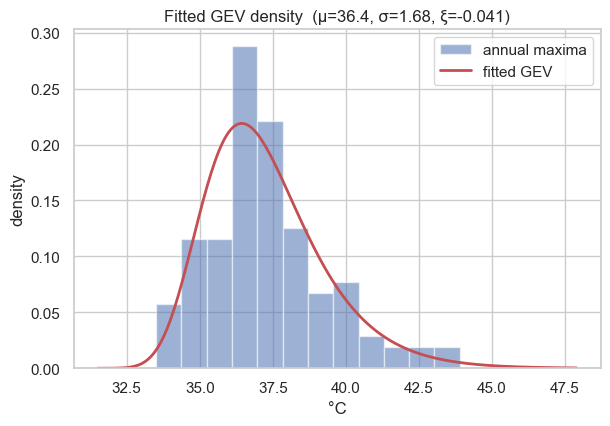

In [9]:
grid = jnp.linspace(zs.min() - 2, zs.max() + 4, 250)
fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.hist(y_np, bins=12, density=True, color="#4C72B0", alpha=0.55, label="annual maxima")
ax.plot(grid, jnp.exp(fit.log_prob(grid)), color="#C44E52", lw=2, label="fitted GEV")
ax.set(xlabel="°C", ylabel="density",
       title=f"Fitted GEV density  (μ={mu_m:.1f}, σ={sig_m:.2f}, ξ={xi_m:+.3f})")
ax.legend()
plt.show()

**Goodness-of-fit scores.** Finally, a few scalar summaries: the maximised
log-likelihood {eq}`eq:gev-loglik`, the information criteria
$\mathrm{AIC}=2k-2\ell$ and $\mathrm{BIC}=k\log m-2\ell$ ($k=3$), the
Kolmogorov–Smirnov statistic $D=\max_i|\hat G(z_{(i)})-p_i|$, and the continuous
ranked probability score (CRPS), estimated from samples of the fitted GEV.

In [10]:
logL = float(jnp.sum(gev_log_prob(y, mu_m, sig_m, xi_m)))
k = 3
aic = 2 * k - 2 * logL
bic = k * np.log(m) - 2 * logL
ks = float(np.max(np.abs(cdf_fit - p)))

# CRPS(F, y) = E|Y - y| - 0.5 E|Y - Y'|, estimated from GEV samples
samp = np.asarray(fit.sample(jr.PRNGKey(7), (5000,)))
e_yz = np.mean(np.abs(samp[:, None] - y_np[None, :]))       # mean over samples & obs
e_yy = np.mean(np.abs(samp[:, None] - samp[None, :]))
crps = float(e_yz - 0.5 * e_yy)

scores = pd.Series({
    "log-likelihood": logL, "AIC": aic, "BIC": bic,
    "KS statistic": ks, "CRPS (°C)": crps,
})
print(scores.round(3).to_string())

log-likelihood   -246.697
AIC               499.394
BIC               507.756
KS statistic        0.078
CRPS (°C)           1.102


The diagonal-hugging PP/QQ points, the density tracking the histogram, and a
small KS statistic together say the GEV is an adequate model for this station —
so we can trust it for the prediction that follows.

## Return levels: predicting the rare

Fitting the GEV is not the goal — *prediction* is. The **$T$-year return level**
$z_T$ is the level the annual maximum exceeds on average once every $T$ years;
equivalently it is the $\left(1-\tfrac1T\right)$ quantile of the fitted GEV
{eq}`eq:gev-cdf`,

```{math}
:label: eq:gev-rl
z_T \;=\; \mu + \frac{\sigma}{\xi}\!\left[\bigl(-\log(1-1/T)\bigr)^{-\xi} - 1\right]
\qquad (\xi \neq 0),
```

with the Gumbel limit $z_T = \mu - \sigma\log\!\bigl(-\log(1-1/T)\bigr)$ as
$\xi\to 0$. Two points deserve emphasis:

- **It is extrapolation.** From only $m$ years of record we routinely read off
  the 100- or 200-year level — far beyond anything observed. So the *uncertainty*
  on $z_T$ is the headline, not the point estimate; the Bayesian posterior hands
  it to us as a band that **widens with $T$**.
- **The shape $\xi$ drives the extrapolation.** For $\xi<0$ the curve bends
  toward the finite upper bound $\mu-\sigma/\xi$; for $\xi>0$ it keeps rising.
  The wide $\xi$ posterior from the fit is exactly why the band fans out at long
  return periods.

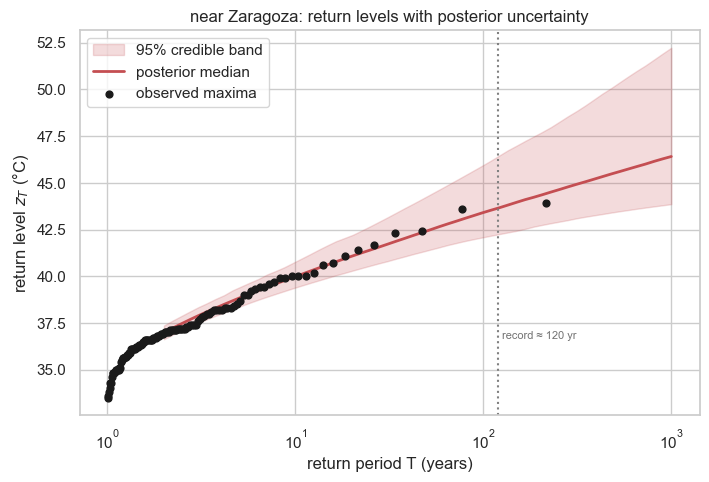

In [11]:
periods = jnp.logspace(np.log10(2), 3, 60)
sub = jr.choice(jr.PRNGKey(3), post["mu"].size, (800,), replace=False)
rl = np.asarray(jax.vmap(lambda i: GEV(loc=post["mu"][i], scale=post["sigma"][i],
                         concentration=post["xi"][i]).return_level(periods))(sub))
rl_med, rl_lo, rl_hi = (np.quantile(rl, q, 0) for q in (0.5, 0.025, 0.975))
emp_T = 1.0 / (1.0 - (np.arange(1, m + 1) - 0.44) / (m + 0.12))   # Gringorten

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(np.asarray(periods), rl_lo, rl_hi, color="#C44E52", alpha=0.2,
                label="95% credible band")
ax.plot(np.asarray(periods), rl_med, color="#C44E52", lw=2, label="posterior median")
ax.scatter(emp_T, zs, color="k", s=24, zorder=5, label="observed maxima")
ax.axvline(m, ls=":", color="0.5")
ax.text(m * 1.05, rl_lo.min(), f"record ≈ {m} yr", color="0.45", fontsize=8)
ax.set_xscale("log")
ax.set(xlabel="return period T (years)", ylabel=r"return level $z_T$ (°C)",
       title=f"{place}: return levels with posterior uncertainty")
ax.legend()
plt.show()

In [12]:
rows = []
for T in (10, 25, 50, 100, 200):
    rT = np.asarray(GEV(loc=post["mu"][sub], scale=post["sigma"][sub],
                        concentration=post["xi"][sub]).return_level(jnp.array(float(T))))
    rows.append((T, np.median(rT), np.quantile(rT, 0.025), np.quantile(rT, 0.975)))
rl_table = pd.DataFrame(rows, columns=["T (yr)", "median °C", "lower 95%",
                                       "upper 95%"]).set_index("T (yr)")
print(rl_table.round(2).to_string())

        median °C  lower 95%  upper 95%
T (yr)                                 
10          39.99      39.40      40.78
25          41.40      40.56      42.67
50          42.43      41.38      44.27
100         43.41      42.09      45.95
200         44.32      42.73      47.66


Drawing those levels back onto the record makes the prediction concrete — the observed maxima cluster around the location μ̂, while the return levels sit progressively further above the data, their bands widening with the return period:

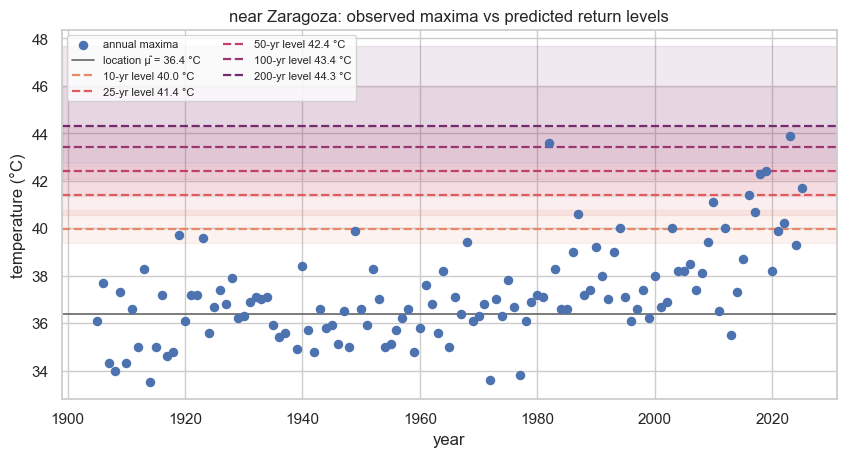

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.scatter(yr_s, y_np, color="#4C72B0", s=34, zorder=5, label="annual maxima")
ax.axhline(mu_m, color="0.4", lw=1.2, label=f"location μ̂ = {mu_m:.1f} °C")
band = sns.color_palette("flare", len(rl_table))
for (T, row), c in zip(rl_table.iterrows(), band):
    ax.axhspan(row["lower 95%"], row["upper 95%"], color=c, alpha=0.10)
    ax.axhline(row["median °C"], color=c, ls="--", lw=1.6,
               label=f"{T}-yr level {row['median °C']:.1f} °C")
ax.set(xlabel="year", ylabel="temperature (°C)",
       title=f"{place}: observed maxima vs predicted return levels")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.show()

Reading the table: each row is a predicted design temperature and its 95%
credible interval, and the interval **widens as $T$ grows** — predicting a
200-year event from a few decades of data is genuine extrapolation. An engineer
sizing for heat risk would use the *upper* bound, not the median. The width also
previews why pooling helps: borrowing strength across nearby stations (later
notebooks) sharpens $\xi$ and tightens exactly these bands.

## Recap & where next

We developed the GEV {eq}`eq:gev-cdf`, fit it to one station by Bayesian
inference {eq}`eq:posterior`, checked that it fits, and used it to **predict**
return levels with honest uncertainty {eq}`eq:gev-rl`. The wide $\xi$ posterior —
and the fan-out of the return-level band — flags that estimating tails
station-by-station is noisy. In [](03_extremal_types.ipynb) we confront that head-on: the three
extreme-value families ξ selects are nearly indistinguishable on a single record
yet predict very different extremes. Later we **pool across stations** with a
spatial Gaussian process to tame that noise.